In [27]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import imblearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [28]:
import pandas as pd

data = pd.read_excel("../dataset/loan_prediction.xlsx")

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [29]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [30]:
data.shape

(614, 13)

In [31]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), object(1), str(7)
memory usage: 62.5+ KB


In [33]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [34]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [35]:
data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


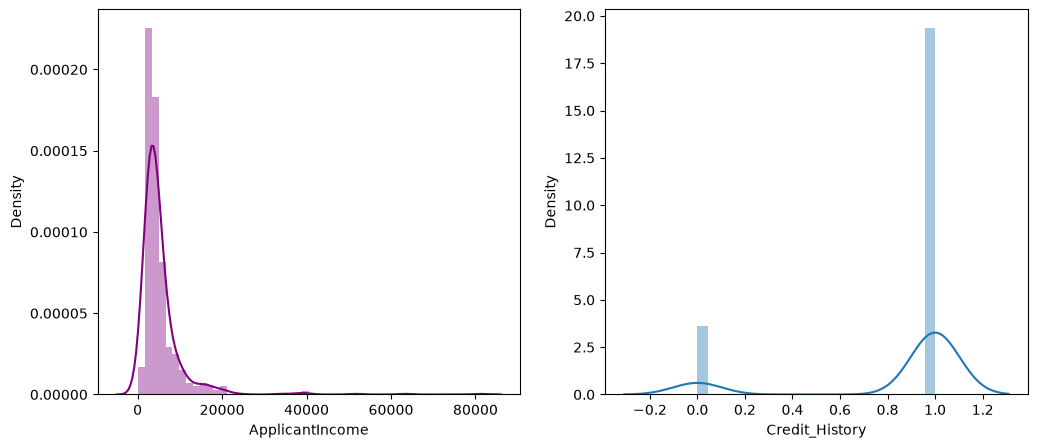

In [36]:
# plotting using distplot

plt.figure(figsize=(12, 5))

plt.subplot(121)
sns.distplot(data['ApplicantIncome'], color='purple')

plt.subplot(122)
sns.distplot(data['Credit_History'])

plt.show()

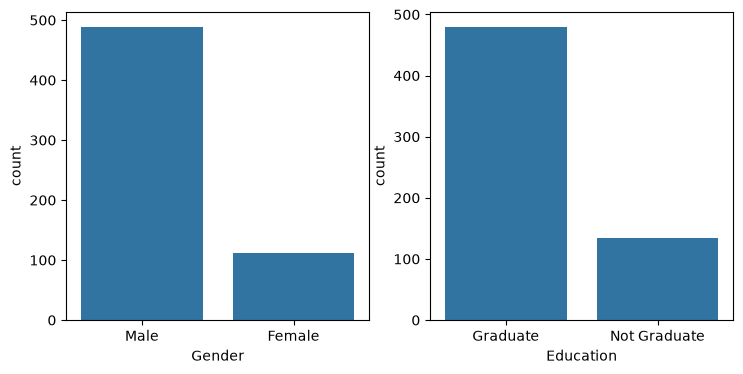

In [37]:
# plotting the count plot

plt.figure(figsize=(18, 4))

plt.subplot(1,4,1)
sns.countplot(x=data['Gender'])

plt.subplot(1,4,2)
sns.countplot(x=data['Education'])

plt.show()

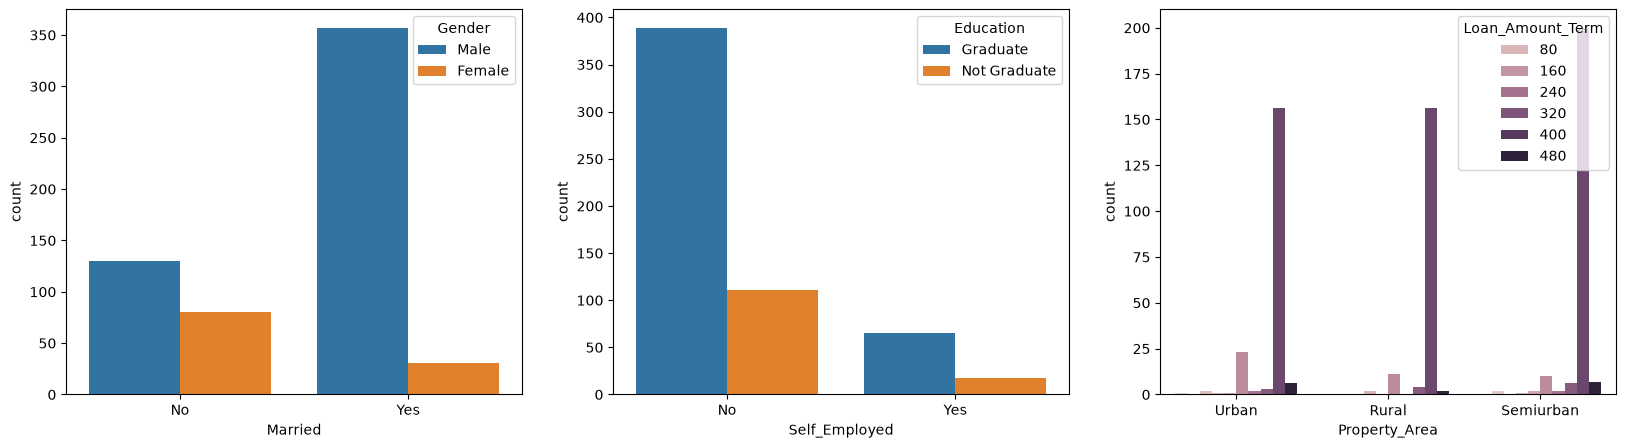

In [38]:
# visualising two columns against each other

plt.figure(figsize=(20, 5))

plt.subplot(131)
sns.countplot(x='Married', hue='Gender', data=data)

plt.subplot(132)
sns.countplot(x='Self_Employed', hue='Education', data=data)

plt.subplot(133)
sns.countplot(x='Property_Area', hue='Loan_Amount_Term', data=data)

plt.show()

<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

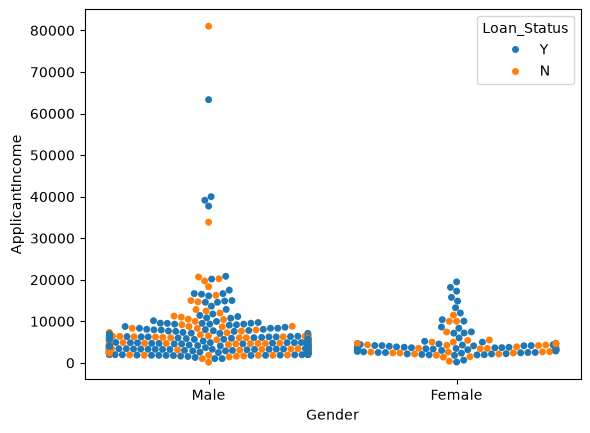

In [39]:
#visulaized based gender and income what would be the application status

sns.swarmplot(x=data['Gender'], y=data['ApplicantIncome'], hue=data['Loan_Status'])

In [40]:
data.shape

(614, 13)

In [41]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), object(1), str(7)
memory usage: 62.5+ KB


In [42]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [43]:
data['Gender'] = data['Gender'].map({'Female':1, 'Male':0})

data['Property_Area'] = data['Property_Area'].map({
    'Urban':2,
    'Semiurban':1,
    'Rural':0
})

data['Married'] = data['Married'].map({
    'Yes':1,
    'No':0
})

data['Education'] = data['Education'].map({
    'Graduate':1,
    'Not Graduate':0
})

data['Loan_Status'] = data['Loan_Status'].map({
    'Y':1,
    'N':0
})

In [44]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0,1,No,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,0.0,1.0,1,1,No,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0.0,1.0,0,1,Yes,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0.0,1.0,0,0,No,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0.0,0.0,0,1,No,6000,0.0,141.0,360.0,1.0,2,1


In [45]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [46]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode().iloc[0])


In [47]:
print(data.columns)

print(data['Gender'].unique())

print(data['Gender'].value_counts(dropna=False))

data.head(10)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')
[0. 1.]
Gender
0.0    502
1.0    112
Name: count, dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0,1,No,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,0.0,1.0,1,1,No,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0.0,1.0,0,1,Yes,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0.0,1.0,0,0,No,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0.0,0.0,0,1,No,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,0.0,1.0,2,1,Yes,5417,4196.0,267.0,360.0,1.0,2,1
6,LP001013,0.0,1.0,0,0,No,2333,1516.0,95.0,360.0,1.0,2,1
7,LP001014,0.0,1.0,3+,1,No,3036,2504.0,158.0,360.0,0.0,1,0
8,LP001018,0.0,1.0,2,1,No,4006,1526.0,168.0,360.0,1.0,2,1
9,LP001020,0.0,1.0,1,1,No,12841,10968.0,349.0,360.0,1.0,1,0


In [48]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import sklearn
import xgboost

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import warnings
warnings.filterwarnings("ignore")

In [49]:
data = pd.read_excel("../dataset/loan_prediction.xlsx")

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [50]:
data.shape

(614, 13)

In [51]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), object(1), str(7)
memory usage: 62.5+ KB


In [52]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [53]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

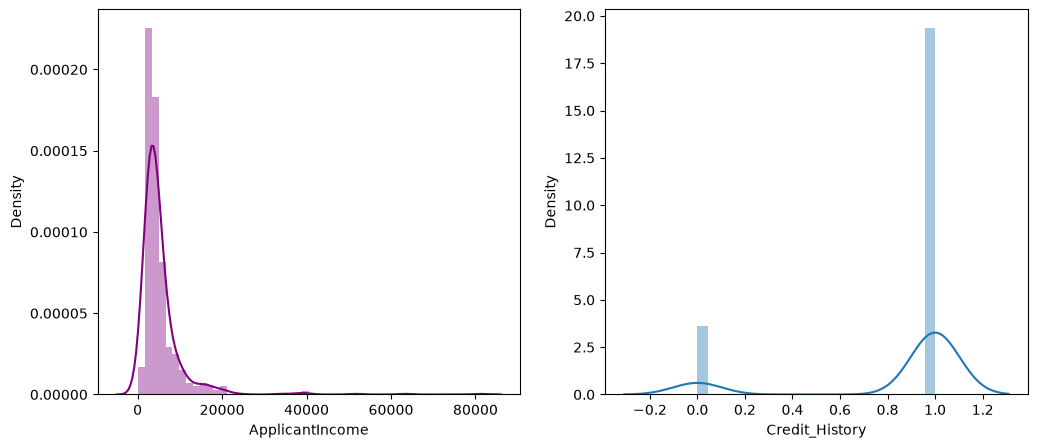

In [54]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.distplot(data['ApplicantIncome'], color='purple')

plt.subplot(122)
sns.distplot(data['Credit_History'])

plt.show()

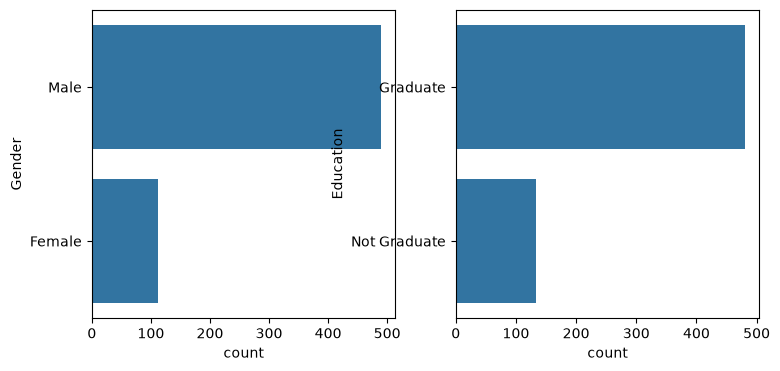

In [55]:
plt.figure(figsize=(18,4))

plt.subplot(1,4,1)
sns.countplot(data['Gender'])

plt.subplot(1,4,2)
sns.countplot(data['Education'])

plt.show()

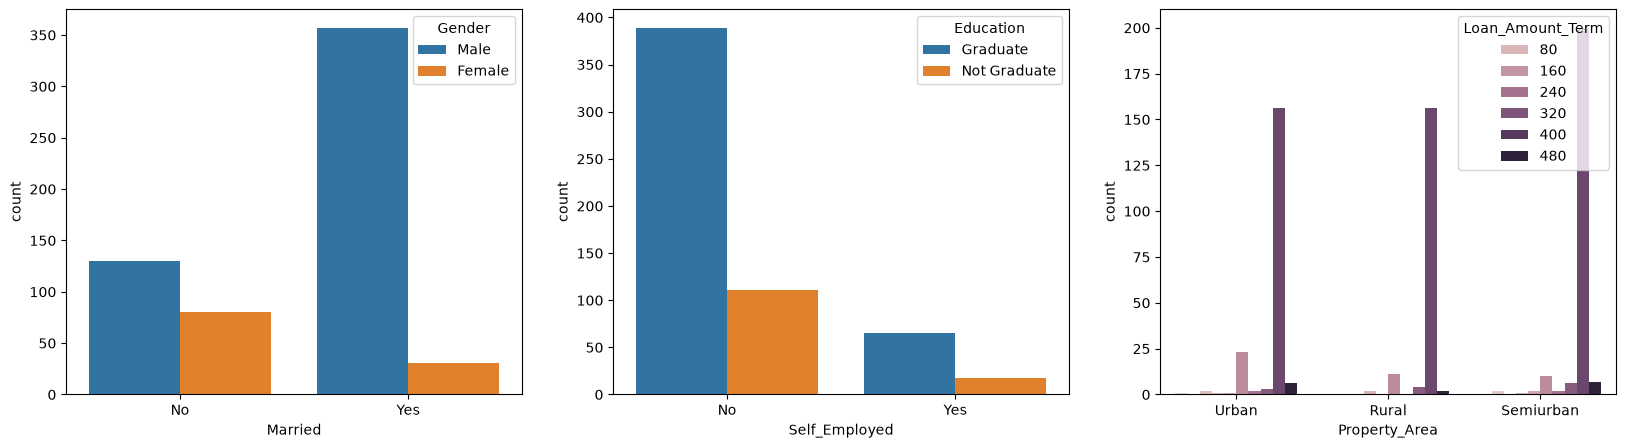

In [56]:
plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(data=data, x='Married', hue='Gender')

plt.subplot(132)
sns.countplot(data=data, x='Self_Employed', hue='Education')

plt.subplot(133)
sns.countplot(data=data, x='Property_Area', hue='Loan_Amount_Term')

plt.show()

In [57]:
plt.figure(figsize=(10,6))

sns.swarmplot(
    data=data,
    x='Gender',
    y='ApplicantIncome',
    hue='Loan_Status'
)

plt.show()

KeyboardInterrupt: 

In [ ]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
# Fill missing values in categorical columns
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])

data['Married'] = data['Married'].fillna(data['Married'].mode()[0])

# Remove '+' from Dependents
data['Dependents'] = data['Dependents'].str.replace('+', '', regex=False)

data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])

data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

# Fill missing values in numerical columns
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mean())

data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])

data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

In [ ]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [ ]:
# Convert categorical values into numerical values

data['Gender'] = data['Gender'].map({'Female': 1, 'Male': 0})

data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})

data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 0})

data['Self_Employed'] = data['Self_Employed'].map({'Yes': 1, 'No': 0})

data['Property_Area'] = data['Property_Area'].map({
    'Rural': 0,
    'Semiurban': 1,
    'Urban': 2
})

data['Loan_Status'] = data['Loan_Status'].map({
    'N': 0,
    'Y': 1
})

# Convert Dependents from string to integer
data['Dependents'] = data['Dependents'].astype(int)

In [ ]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0,0,3,1,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,0,1,3,1,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,0,1,3,1,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,0,1,3,0,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,0,0,3,1,0,6000,0.0,141.000000,360.0,1.0,2,1


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 62.5 KB


In [ ]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [58]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

In [59]:
X = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']

In [ ]:
# Creating new X and y variables for the balanced dataset
X_bal, y_bal = smote.fit_resample(X, y)

In [24]:
# Printing the values of y before and after balancing
print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(y_bal.value_counts())

Before SMOTE:
Loan_Status
1    422
0    192
Name: count, dtype: int64

After SMOTE:
Loan_Status
1    422
0    422
Name: count, dtype: int64


In [25]:
names = X_bal.columns

In [60]:
# Performing feature scaling using StandardScaler
# because the columns have different ranges of values

sc = StandardScaler()

X_bal = sc.fit_transform(X_bal)

In [61]:
X_bal = pd.DataFrame(X_bal, columns=names)

X_bal.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,-0.411066,-1.162314,0.0,0.630358,-0.339009,0.111762,-0.584610,0.011462,0.287946,0.574053,1.359312
1,-0.411066,0.860352,0.0,0.630358,-0.339009,-0.118995,-0.024552,-0.217914,0.287946,0.574053,-1.201535
2,-0.411066,0.860352,0.0,0.630358,2.949771,-0.407532,-0.584610,-0.990302,0.287946,0.574053,1.359312
3,-0.411066,0.860352,0.0,-1.586401,-0.339009,-0.483539,0.291131,-0.317577,0.287946,0.574053,1.359312
4,-0.411066,-1.162314,0.0,0.630358,-0.339009,0.139285,-0.584610,-0.055962,0.287946,0.574053,1.359312


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bal,
    y_bal,
    test_size=0.33,
    random_state=42
)

In [63]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (565, 11)
X_test shape : (279, 11)
y_train shape: (565,)
y_test shape : (279,)


In [64]:
# Importing and building the Decision Tree model

def decisionTree(X_train, X_test, y_train, y_test):
    
    model = DecisionTreeClassifier(random_state=42)

    # Training the model
    model.fit(X_train, y_train)

    # Prediction on training data
    y_tr = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, y_tr))

    # Prediction on testing data
    yPred = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, yPred))

    return model

In [65]:
# Printing the training accuracy and testing accuracy

dt_model = decisionTree(X_train, X_test, y_train, y_test)

Training Accuracy: 1.0
Testing Accuracy: 0.7670250896057348


In [66]:
# Importing and building the Random Forest model

def RandomForest(X_train, X_test, y_train, y_test):

    model = RandomForestClassifier(random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Predict on training data
    y_tr = model.predict(X_train)

    print("Training Accuracy :", accuracy_score(y_train, y_tr))

    # Predict on testing data
    yPred = model.predict(X_test)

    print("Testing Accuracy  :", accuracy_score(y_test, yPred))

    return model

In [67]:
# Printing the training accuracy and testing accuracy

rf_model = RandomForest(X_train, X_test, y_train, y_test)

Training Accuracy : 1.0
Testing Accuracy  : 0.7849462365591398


In [68]:
# Importing and building the KNN model

def KNN(X_train, X_test, y_train, y_test):

    model = KNeighborsClassifier()

    # Train the model
    model.fit(X_train, y_train)

    # Predict on training data
    y_tr = model.predict(X_train)

    print("Training Accuracy :", accuracy_score(y_train, y_tr))

    # Predict on testing data
    yPred = model.predict(X_test)

    print("Testing Accuracy  :", accuracy_score(y_test, yPred))

    return model

In [69]:
# Printing the training accuracy and testing accuracy

knn_model = KNN(X_train, X_test, y_train, y_test)

Training Accuracy : 0.8424778761061947
Testing Accuracy  : 0.7060931899641577


In [70]:
# Importing and building the XG Boost model

def XGB(X_train, X_test, y_train, y_test):

    model = GradientBoostingClassifier(random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Predict on training data
    y_tr = model.predict(X_train)

    print("Training Accuracy :", accuracy_score(y_train, y_tr))

    # Predict on testing data
    yPred = model.predict(X_test)

    print("Testing Accuracy  :", accuracy_score(y_test, yPred))

    return model

In [71]:
# Printing the training accuracy and testing accuracy

xgb_model = XGB(X_train, X_test, y_train, y_test)

Training Accuracy : 0.9203539823008849
Testing Accuracy  : 0.7921146953405018


In [72]:
import pickle

In [73]:
pickle.dump(xgb_model, open("../model/loan_model.pkl", "wb"))

In [74]:
import os

print(os.listdir("../model"))

['loan_model.pkl']


In [75]:
pickle.dump(sc, open("../model/scaler.pkl", "wb"))